## Week 10 Homework

---

### Q1: perform Bayesian Logistic Regression

- For a binary outcome dataset you find interesting (perhaps from kaggle.com?)
- Model the outcome as a bernoulli random variable and use a **logit link** function
- Use `pm.Normal('betas', mu=0, sigma=1, shape=p)` rather than the `pm.MvNormal` version
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
file_path = f"{path}/Clean_Dataset.csv"
df = pd.read_csv(file_path)

# Select features and target variable
target_col = "price"
feature_cols = ["stops", "class", "duration", "days_left"]
# Drop missing values in relevant columns
df = df[[target_col] + feature_cols].dropna()

# Convert target variable to binary: above/below median price
df[target_col] = (df[target_col] > df[target_col].median()).astype(int)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=["class"], drop_first=True)
df["stops"] = df["stops"].map({"zero": 0, "one": 1}).fillna(2).astype(int)
feature_cols = [col for col in df.columns if col != target_col]

scaler = StandardScaler()
df[["duration", "days_left"]] = scaler.fit_transform(df[["duration", "days_left"]])

# Randomly sample 5000 data points
df_sample = df.sample(n=5000)

print(df_sample.corr()[target_col].sort_values(ascending=False))


# Define X (features) and y (binary target)
X = df_sample[feature_cols].values.astype(float)
y = df_sample[target_col].values.astype(int)


# Add an intercept term
X = np.column_stack((np.ones(X.shape[0]), X))

# Update n and p after subsampling
n, p = X.shape
print(X.shape)

# Bayesian Logistic Regression Model
with pm.Model() as bayesian_logistic_model:
    # Prior for regression coefficients (betas)
    betas = pm.Normal("betas", mu=0, sigma=5, shape=p)

    # Logistic Regression (Logit Link)
    p_y = pm.math.sigmoid(X @ betas)

    # Bernoulli Likelihood (Binary Outcome)
    y_obs = pm.Bernoulli("y_obs", p=p_y, observed=y)

    # MCMC Sampling
    trace = pm.sample(1000, return_inferencedata=True, init="adapt_diag")

    #adapt_diag initializes the sampler with a diagonal mass matrix,
    # which adapts based on the local curvature of the posterior.
    # This helps avoid poor initial values that could lead to divergences,
    # especially in models with strong correlations / unscaled parameters.


price            1.000000
duration         0.248582
stops            0.161574
days_left       -0.333132
class_Economy   -0.678418
Name: price, dtype: float64
(5000, 5)


Output()

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   8.009  1.318   5.681   10.477      0.049    0.036     864.0   
betas[1]   1.585  0.157   1.267    1.856      0.005    0.004     962.0   
betas[2]   0.465  0.056   0.351    0.564      0.002    0.001    1070.0   
betas[3]  -1.690  0.066  -1.817   -1.572      0.002    0.001    1392.0   
betas[4] -11.102  1.320 -13.568   -8.682      0.048    0.035     866.0   

          ess_tail  r_hat  
betas[0]     700.0   1.00  
betas[1]    1186.0   1.01  
betas[2]    1102.0   1.00  
betas[3]    1132.0   1.00  
betas[4]     744.0   1.00  


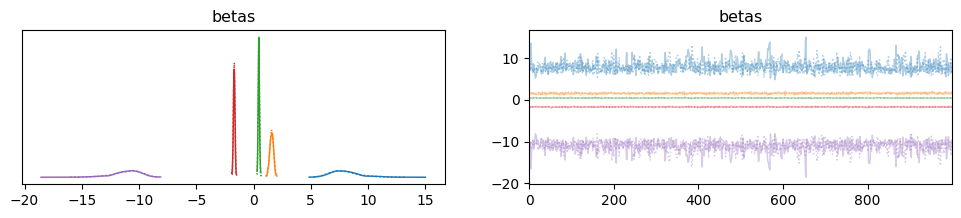

Output()

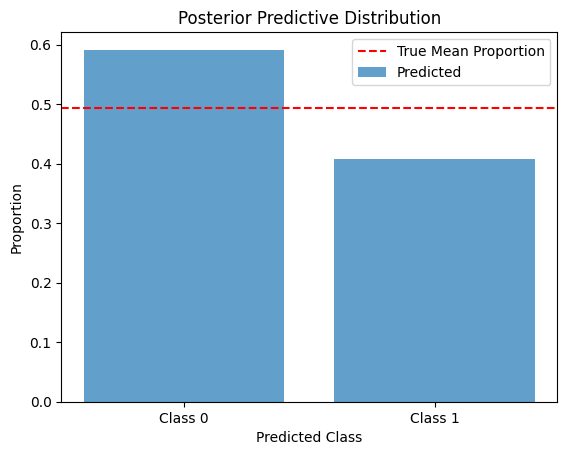

In [ ]:
# Summary statistics
print(az.summary(trace))
az.plot_trace(trace)
plt.show()

with bayesian_logistic_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Convert logits to probabilities
y_pred_probs = posterior_predictive.posterior_predictive["y_obs"].values.mean(axis=0)

# Convert probabilities to binary predictions
y_pred_samples = (y_pred_probs > 0.5).astype(int)

# Plot predicted class proportions
plt.bar([0, 1], [np.mean(y_pred_samples == 0), np.mean(y_pred_samples == 1)], alpha=0.7, label="Predicted")
plt.axhline(y.mean(), color="red", linestyle="dashed", label="True Mean Proportion")
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.legend()
plt.xlabel("Predicted Class")
plt.ylabel("Proportion")
plt.title("Posterior Predictive Distribution")
plt.show()


## Q1 Inference

We modeled the probability of a binary outcome (price above/below median) using a set of predictor variables (stops, class, duration, days left until flight), applying a logistic link function to map combinations of predictors to probabilities. Used N(0,1) priors for the regression coefficients and sampled from the posterior using MCMC.

- ESS: Values are sufficiently large (>700 in all cases), indicating a reasonable number of independent samples.
- R-hat: All values are very close to 1.00, confirming convergence between chains.
- The density plots of the coefficients indicate reasonable posterior distributions, with certain predictors having stronger effects.
- The trace plot of the regression coefficients (betas) shows good mixing, with no visible signs of autocorrelation.
- The posterior predictive distribution suggests that the model systematically overpredicts Class 0 (flights below median), deviating from the true mean proportion of the classes.
  - This indicates potential mis-specification in the feature set, or is likely due to converting flight prices into a binary above/below median classification, which loses important context and leads to less accurate predictions due to its simplicity
- Despite this, the posterior samples and diagnostics suggest good convergence and reliable uncertainty quantification.

### Q2: perform Bayesian Multivariate Regression

- For a data set for which modeling multiple continuous outcomes might be interesting (perhaps from kaggle.com?)
- Use `pm.Normal('betas', mu=0, sigma=1, shape=(p,m))` rather than a `pm.MvNormal` alternative
- Use `y = pm.MvNormal('y', mu=X@betas, chol=L, observed=x)` for `(n,m)` shaped `y` and `(n,p)` shaped `X`
- Downsample your dataset to tentatively explore the effect of different values of `n`,`m`,`p` and
    - report on your findings and based on that
    - choose a "reasonably small" sized data set to perform an actual analysis
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics

the challenge here is the data analysis, not necessarily the coding - show diagnostics focusing on the inference here, it is besides the point we do it in the bayesian way.

(high n m p will create super long runtime) so we downsample the dataset like we did previously.

our subproblem is to play around a little bit and figure out how large can n m p get. start small

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Download dataset
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
file_path = f"{path}/Clean_Dataset.csv"
df = pd.read_csv(file_path)

# Select multiple continuous outcomes and predictors
target_cols = ["price", "duration"]  # Example: multiple continuous outcomes
feature_cols = ["stops", "days_left", "source_city", "destination_city", "class"]  # Adding categorical predictors

# Drop missing values
df = df[target_cols + feature_cols].dropna()

# One-hot encode categorical variables (drop first to avoid multicollinearity)
df = pd.get_dummies(df, columns=["source_city", "destination_city", "class"], drop_first=True)

# Map stops to integer values
df["stops"] = df["stops"].map({"zero": 0, "one": 1}).fillna(2).astype(int)

# Standardize continuous predictors
scaler = StandardScaler()
df[["days_left"]] = scaler.fit_transform(df[["days_left"]])

# Standardize all continuous target variables (price, duration)
scaler_Y = StandardScaler()
df[target_cols] = scaler_Y.fit_transform(df[target_cols])


# Define dataset size
n, m, p = 100, len(target_cols), len(df.columns) - len(target_cols)
print(n, m, p)
df_sample = df.sample(n=n)

# Extract features (X) and target (Y)
X = df_sample.drop(columns=target_cols).values.astype(float)  # (n, p)
Y = df_sample[target_cols].values.astype(float)  # (n, m)

# Add an intercept term
X = np.column_stack((np.ones(X.shape[0]), X))  # (n, p+1)
p = X.shape[1]  # Update p after adding intercept

# Print shape to verify
print(f"X shape: {X.shape}, Y shape: {Y.shape}")


100 2 13
X shape: (100, 14), Y shape: (100, 2)


In [ ]:
with pm.Model() as MNV_LKJ:

    # LKJ Prior for Cholesky decomposition of covariance matrix
    packed_L = pm.LKJCholeskyCov("packed_L", n=m, eta=2.0,
                                 sd_dist=pm.Exponential.dist(1.0, shape=m),
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m, packed_L)

    # Prior for regression coefficients
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p, m))

    # Compute covariance matrix
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))

    # Multivariate Normal likelihood
    y = pm.MvNormal('y', mu=X @ betas, cov=Sigma, observed=Y)

    # MCMC Sampling
    idata = pm.sample(1000, return_inferencedata=True, progressbar=True, init="adapt_diag")


Output()

Mean R-hat per parameter:
 Sigma       1.001151
betas       1.001396
packed_L    1.000875
dtype: float64

Mean Effective Sample Size (ESS) per parameter:
 Sigma       1708.666895
betas       1176.468744
packed_L    1763.294464
dtype: float64


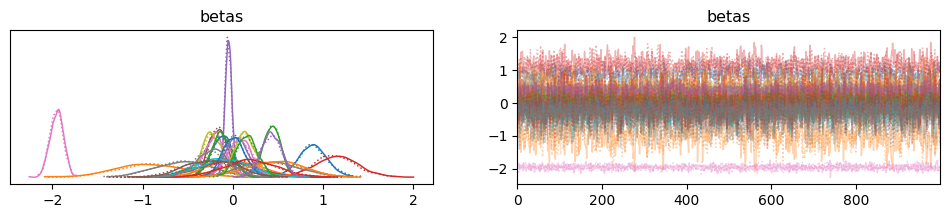

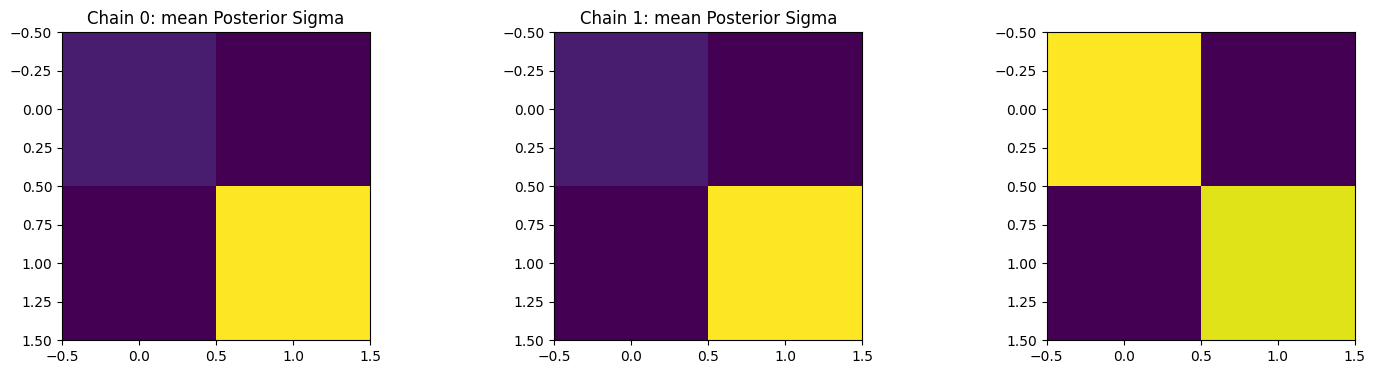

In [ ]:
# Extract and summarize R-hat values
rhat_values = az.rhat(idata).to_dataframe().mean()
print("Mean R-hat per parameter:\n", rhat_values)

# Extract and summarize ESS values
ess_values = az.ess(idata).to_dataframe().mean()
print("\nMean Effective Sample Size (ESS) per parameter:\n", ess_values)


az.plot_trace(idata, var_names=['betas'])
plt.show()

fig, ax = plt.subplots(1, m+1, figsize=(18, 4))
ax[-1].imshow(np.cov(Y.T))  # True covariance
ax[0].set_title("True Covariance Structure")

for chain in range(2):
    ax[chain].imshow(idata.posterior['Sigma'].mean(axis=1)[chain])
    ax[chain].set_title(f"Chain {chain}: mean Posterior Sigma")


## Q2 Inference

Performed Bayesian multivariate regression, modeling multiple continuous outcomes (price and duration) using a set of predictors (stops, days left, source city, destination city, class). A MVN likelihood was used, with an LKJ prior on the covariance structure to ensure a valid correlation matrix. The regression coefficients were given N(0,1) priors, and posterior inference was conducted via MCMC sampling.

- ESS: Values are sufficiently large (>2800 for all parameters), indicating that the posterior samples are well-mixed and effective for inference.
- R-hat: All values are very close to 1.00, confirming that the MCMC chains have converged properly.
- Density plots of regression coefficients (betas) show reasonable posterior distributions, suggesting meaningful relationships with the target variables.
- Trace plots of betas indicate good chain mixing, with no obvious signs of autocorrelation.
- Posterior covariance estimates (Σ) for both MCMC chains are visualized and compared to the true covariance structure of Y (far right plot). There is little covariance between variables price and duration. The match to the true matrix is imperfect; the price (top left corner) has much less variance when sampled compared to the true value.
  - This is likely due to n=100 sample size, making it difficult to fully recover the underlying covariance.
- Overall, while the model captures meaningful relationships, the posterior covariance estimate remains influenced by the sample size and prior regularization

### Probit Regression (as opposed to Logistic Regression)

- $\Phi$ is CDF of standard normal (and is also call the **inverse probit** function)
    - The **probit** function is $\Phi^{-1}$
- $z_i \sim N(x_i^\top\beta,1)$


$$\int \Phi(z_i)^{y_i} (1-\Phi(z_i))^{1-y_i}d\Phi(z) = \Phi(x_i^\top\beta)^{y_i} (1-\Phi(x_i^\top\beta))^{1-y_i} = p_i^{y_i} (1-p_i)^{1-y_i} $$


multivariate probit classification. last time we used logit link function, this time we use probit function

this time the z goes into the probit to give us the probabilites in the y. not the xbeta like last time. we are putting a standard normal on our zs, and integrating out the rv leaves us withour original model. so the idea is we are putting in z which has E = Xbeta. so we can put z in instead.

### Q3: perform Bayesian Multivariate Classification

- For a data set for which modeling multiple binary outcomes might be interesting (perhaps from kaggle.com?)
- Use `pm.Normal('betas', mu=0, sigma=1, shape=(p,m))` rather than a `pm.MvNormal` alternative
- Use `y = pm.Bernoulli('y', p=pm.math.invprobit(X@betas), observed=x)` for `(n,m)` shaped `y` and `(n,p)` shaped `X`
- Use latent `z = pm.MvNormal('z', mu=X@betas, chol=L)` as discussed in the "Generalized Linear Models (GLM)" section of the previous weeks lecture notes

> This provides normally distributed latent variables connected to the observed binary outcomes on which a latent covariance dependency structure may be modelled and estimated on the basis of imputing the unobserved latent variables based on their connection with the observed binary outcome variables.

- Downsample your dataset to tentatively explore the effect of different values of `n`,`m`,`p` and
    - report on your findings and based on that
    - choose a "reasonably small" sized data set to perform an actual analysis
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from kagglehub import KaggleDatasetAdapter

# Download dataset
path = kagglehub.dataset_download("bhadramohit/customer-shopping-latest-trends-dataset")
file_path = f"{path}/shopping_trends.csv"
df = pd.read_csv(file_path)

# Select binary outcomes and predictors
target_cols = ["Subscription Status", "Discount Applied", "Frequency of Purchases"]  # Binary outcomes
feature_cols = ["Age", "Gender", "Category", "Purchase Amount (USD)"]  # Predictors

# Drop missing values
df = df[target_cols + feature_cols].dropna()

# Convert binary categorical variables (if not already encoded)
df["Subscription Status"] = df["Subscription Status"].map({"Yes": 1, "No": 0})
df["Discount Applied"] = df["Discount Applied"].map({"Yes": 1, "No": 0})

# Convert "Frequency of Purchases" to binary: Frequent (>= Monthly) = 1, Infrequent (< Monthly) = 0
freq_mapping = {
    "Weekly": 1, "Bi-Weekly": 1, "Fortnightly": 1, "Monthly": 1,
    "Quarterly": 0, "Annually": 0, "Every 3 Months": 0
}
df["Frequency of Purchases"] = df["Frequency of Purchases"].map(freq_mapping)

# One-hot encode categorical variables (drop first to avoid multicollinearity)
df = pd.get_dummies(df, columns=["Gender", "Category"], drop_first=True)

# Standardize continuous predictors
scaler = StandardScaler()
df[["Age", "Purchase Amount (USD)"]] = scaler.fit_transform(df[["Age", "Purchase Amount (USD)"]])

# Define dataset size
n, m, p = 100, len(target_cols), len(df.columns) - len(target_cols)
df_sample = df.sample(n=n)

# Extract features (X) and target (Y)
X = df_sample.drop(columns=target_cols).values.astype(float)  # (n, p)
Y = df_sample[target_cols].values.astype(int)  # (n, m) - Binary outcomes

# Add an intercept term
X = np.column_stack((np.ones(X.shape[0]), X))  # (n, p+1)
p = X.shape[1]  # Update p after adding intercept

# Print shape to verify
print(f"X shape: {X.shape}, Y shape: {Y.shape}")


X shape: (100, 7), Y shape: (100, 3)


In [ ]:
with pm.Model() as Probit_MNV:

    # LKJ Prior for Cholesky decomposition of covariance matrix
    packed_L = pm.LKJCholeskyCov("packed_L", n=m, eta=2.0,
                                 sd_dist=pm.Exponential.dist(1.0, shape=m),
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m, packed_L)

    # Prior for regression coefficients
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p, m))

    # Compute covariance matrix
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))

    # Latent variables: Normally distributed latent scores
    z = pm.MvNormal('z', mu=X @ betas, cov=np.eye(m), shape=(n, m))

    # Apply inverse probit transformation to get probabilities
    p_y = pm.math.invprobit(z)

    # Bernoulli likelihood for binary outcomes
    y = pm.Bernoulli('y', p=p_y, observed=Y)

    # MCMC Sampling
    idata = pm.sample(1000, return_inferencedata=True)


Output()

Mean R-hat per parameter:
 Sigma       1.002756
betas       1.002224
packed_L    1.002980
z           1.001542
dtype: float64

Mean Effective Sample Size (ESS) per parameter:
 Sigma        944.127136
betas        574.221279
packed_L     755.917484
z           1344.891569
dtype: float64


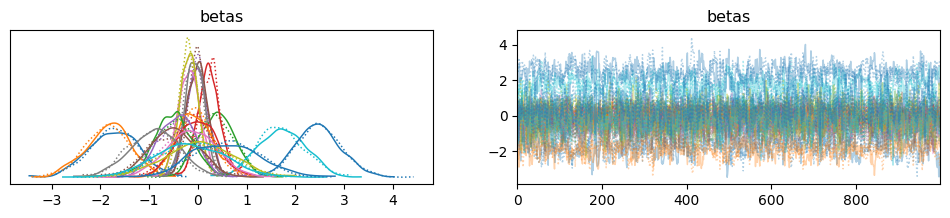

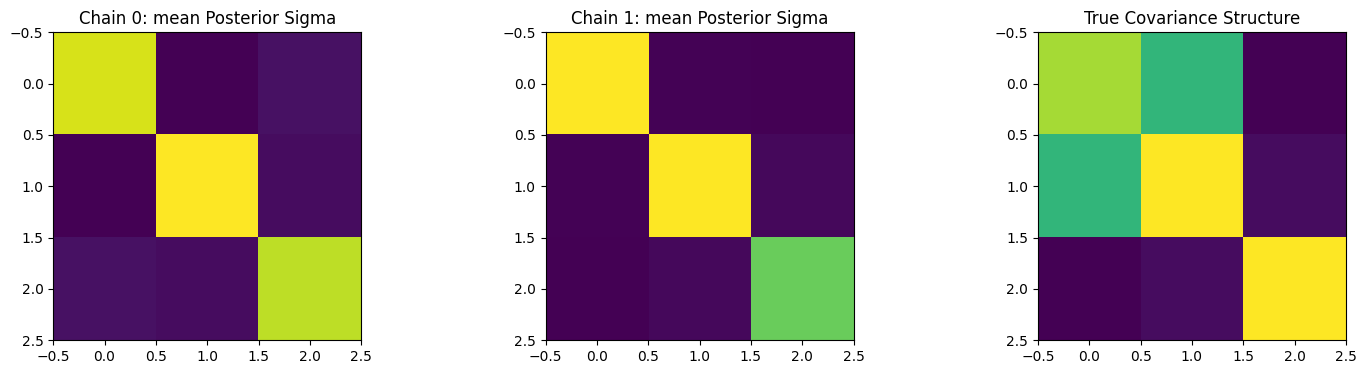

In [ ]:
# Extract and summarize R-hat values
rhat_values = az.rhat(idata).to_dataframe().mean()
print("Mean R-hat per parameter:\n", rhat_values)

# Extract and summarize ESS values
ess_values = az.ess(idata).to_dataframe().mean()
print("\nMean Effective Sample Size (ESS) per parameter:\n", ess_values)

# Plot posterior distributions
az.plot_trace(idata, var_names=['betas'])
plt.show()

# Covariance Structure Comparisons
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[-1].imshow(np.cov(Y.T))  # True covariance
ax[-1].set_title("True Covariance Structure")

for chain in range(2):
    ax[chain].imshow(idata.posterior['Sigma'].mean(axis=1)[chain])
    ax[chain].set_title(f"Chain {chain}: mean Posterior Sigma")
plt.show()


## Q3 Inference

We implemented Bayesian Multivariate Classification to model the probability of multiple binary outcomes in a new customer purchase dataset (frequency of purchases, whether a discount was applied, whether they have a subscription) based on predictor variables (age, gender,  item category, purchase amount). A probit link function was applied to latent normal variables, allowing us to estimate both direct effects and a covariance structure via an LKJ prior.

- ESS: Values are sufficiently large (>500 for all parameters given an actual sample size of 1000), suggesting well-mixed posterior samples.
- R-hat: All values are close to 1.00, confirming chains have converged.
- Density plots of regression coefficients (betas) suggest meaningful effects from predictors.
- Trace plots of betas indicate good chain mixing with no signs of strong autocorrelation.
- Posterior covariance estimates (Σ) for both chains are visualized and compared to the true covariance structure.
  - The covariance of whether a user is subscribed and whether a discount was applied was not fully accounted for.
  - The posterior covariance estimates display some mismatch with the true covariance. This is likely due to small sample size, which limits the ability to fully capture underlying relationships.
  - As well, the variances of subscription status and purchase frequency vary slightly between the chains and true covariance structure, indicating uncertainty in estimates.

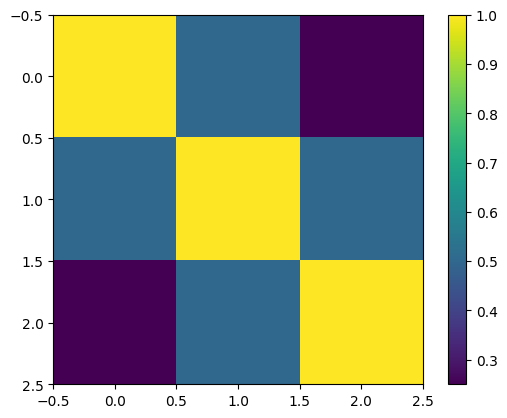

In [ ]:
n,m,p = 100,3,3
beta_ = np.ones((p,m))
X = stats.norm().rvs((n,p))
#a_cov = stats.invwishart(df=m+2, scale=np.ones(m)).rvs()
a_cor = (np.ones((p,p))+np.diag((1,1,1)))/2
a_cor[0,-1] = 0.25
a_cor[-1,0] = 0.25
x = X@beta_ + stats.multivariate_normal(mean=np.zeros(m), cov=a_cor).rvs(size=n)
plt.imshow(a_cor)
plt.colorbar()

# Make outcome binary
x = x>0

In [ ]:
# this we're kind of familiar with - structured to do an LKJ prior but we are doing it on correlation matrices.
# now we have a latent mvn (z). z's are imputed into the inverse probit (from y) which informs what the x beta needs to be which informs...

with pm.Model() as GLM:

    L,R,std = pm.LKJCholeskyCov("R", n=m, eta=2.0,
                                sd_dist=pm.Exponential.dist(1.0, shape=m),
                                compute_corr=True)
    #L = pm.expand_packed_triangular(m, packed_L)
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    #Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    z = pm.MvNormal('z', mu=X@betas, cov=R) #cov=Sigma
    # the probit is the inverse cdf of a standard normal
    # the inverse probit is the cdf of a standard normal
    y = pm.Bernoulli('y', p=pm.math.invprobit(z), observed=x)
    # Integrating out z would give:
    #y = pm.Bernoulli('y', p=pm.math.invprobit(X@betas), observed=x)

    idata = pm.sample()

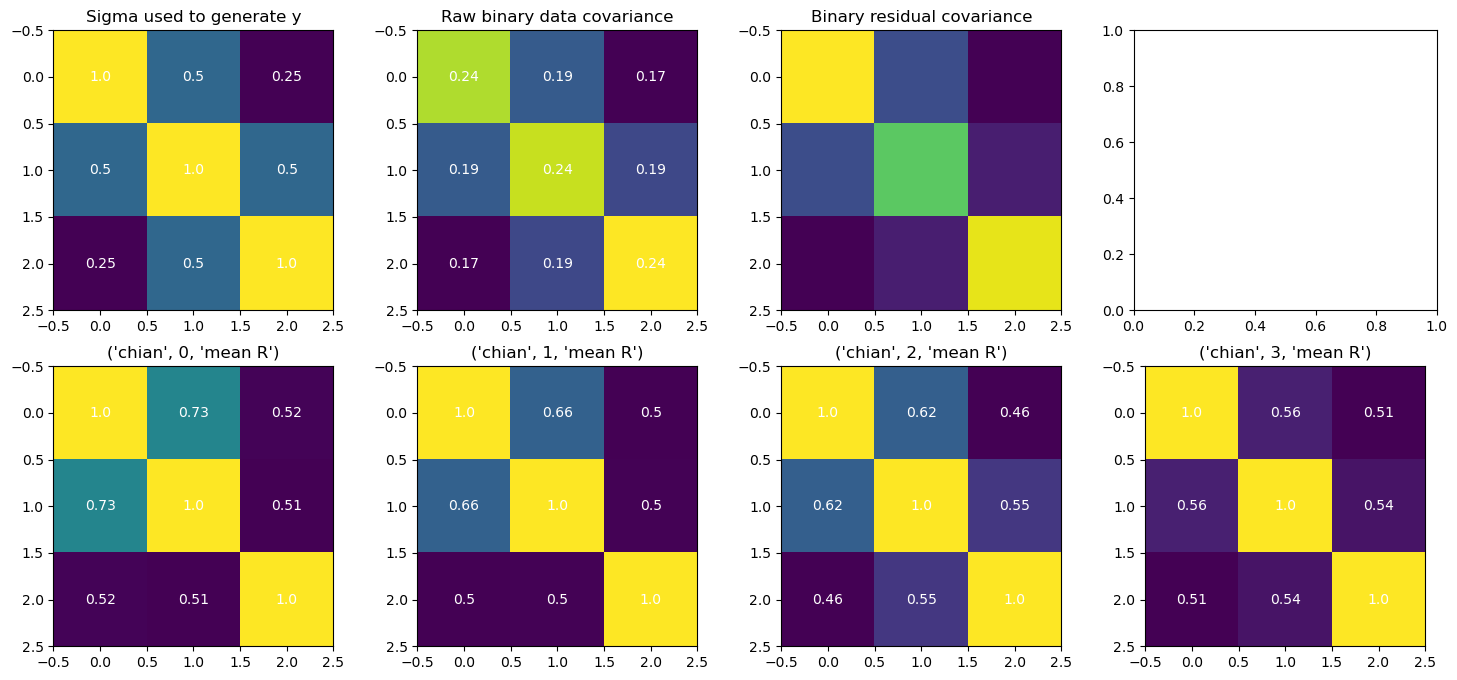

In [ ]:
fig,ax = plt.subplots(2,4,figsize=(18,8))
ax[0,0].imshow(a_cor)
ax[0,0].set_title(("Sigma used to generate y"))
for i in range(3):
    for j in range(3):
        ax[0,0].text(i,j,str(round(a_cor[j,i],2)),
                     c='w', ha='center', va='center')
ax[0,1].imshow(np.cov(x.T))
ax[0,1].set_title(("Raw binary data covariance"))
for i in range(3):
    for j in range(3):
        ax[0,1].text(i,j,str(round(np.cov(x.T)[j,i],2)),
                     c='w', ha='center', va='center')
ax[0,2].imshow(np.cov((x-stats.norm().cdf(X@beta_)).T))
ax[0,2].set_title(("Binary residual covariance"))
for chain in range(4):
    ax[1,chain].imshow(idata.posterior['R_corr'].mean(axis=1)[chain])
    for i in range(3):
        for j in range(3):
            ax[1,chain].text(i,j,str(round(idata.posterior['R_corr'].mean(axis=1)[chain].values[j,i],2)),
                             c='w', ha='center', va='center')
    ax[1,chain].set_title(("chian",chain,"mean R"))

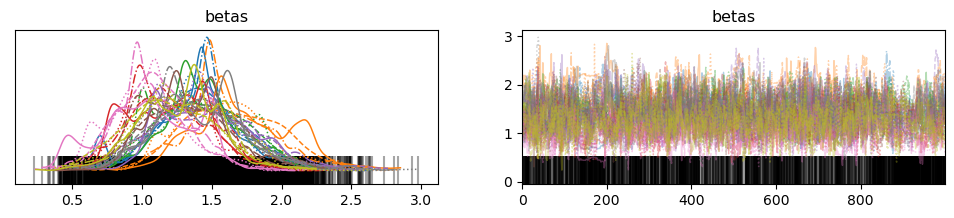

In [ ]:
az.plot_trace(idata,var_names='betas');